In [1]:
import pandas as pd

income = pd.read_csv("income.csv")
print(income.head())


   Age  Education  Salary
0   25  Bachelors    43.9
1   30  Bachelors    54.4
2   45  Bachelors    62.5
3   55  Bachelors    72.5
4   65  Bachelors    74.6


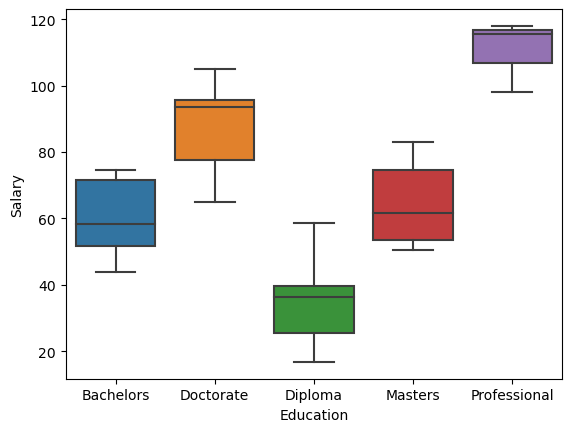

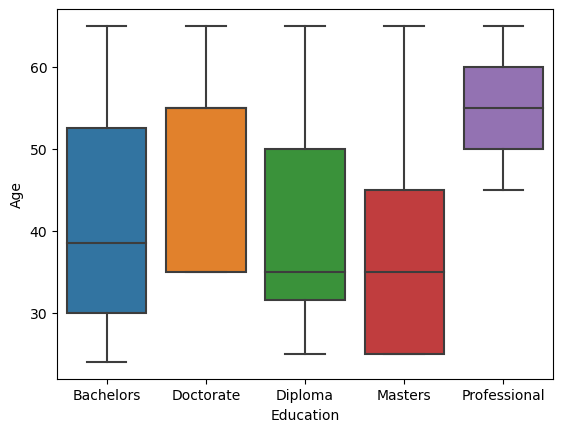

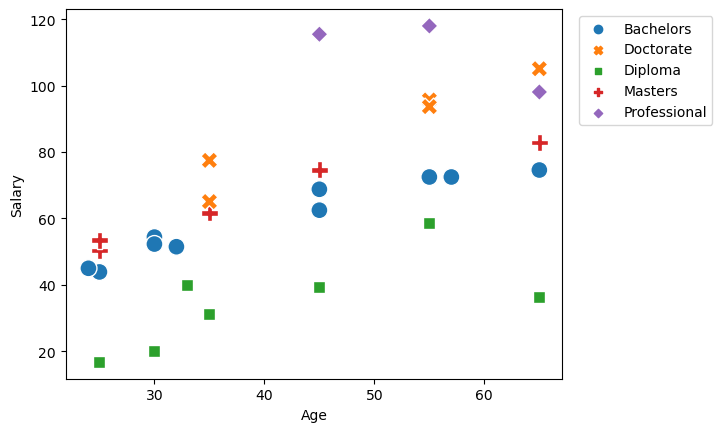

In [3]:
# =========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplots
sns.boxplot(data=income, x='Education', y='Salary')
plt.show()

sns.boxplot(data=income, x='Education', y='Age')
plt.show()

# Scatter plot
sns.scatterplot(data=income,
                x='Age',
                y='Salary',
                hue='Education',
                style='Education',
                s=150)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()



In [4]:
X = income[['Age', 'Education']]
y = income['Salary']

# Convert categorical to numeric
X = pd.get_dummies(X, drop_first=True)

# Train-test split (NO stratify for regression)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.6,
    random_state=1234
)

print(X_train.shape, X_test.shape)

(18, 5) (12, 5)


In [5]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Train model
regressor = DecisionTreeRegressor(random_state=1234)
model = regressor.fit(X_train, y_train)

# Predictions
y_test_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2 Score:", r2_score(y_test, y_test_pred))

MAE: 18.275
R2 Score: 0.1605852764261383


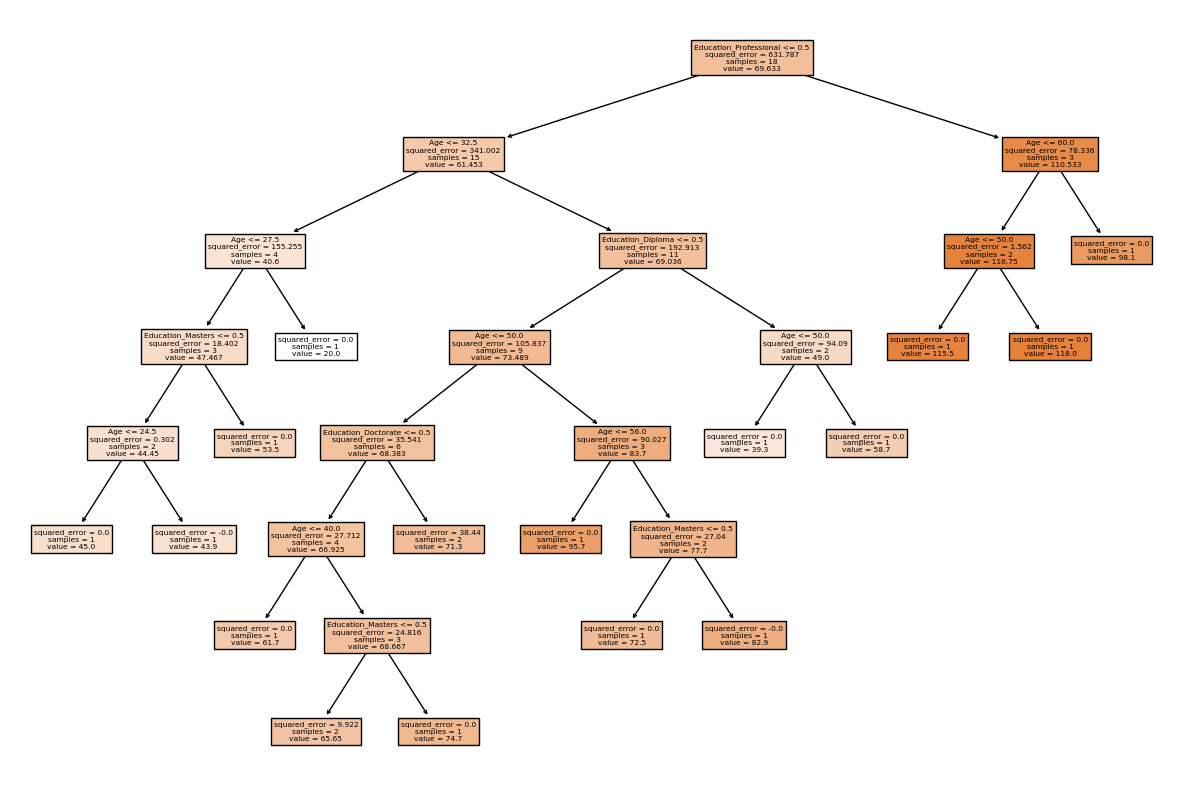

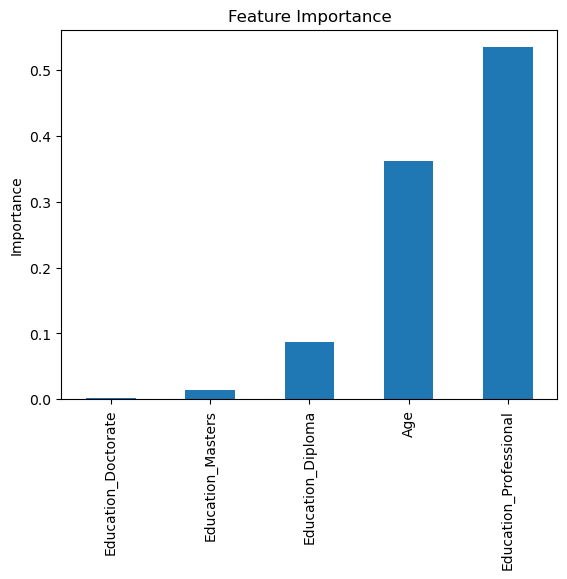

In [6]:
from sklearn import tree

plt.figure(figsize=(15, 10))
tree.plot_tree(model,
               feature_names=X_train.columns,
               filled=True)
plt.show()

# Feature Importance
importance = model.feature_importances_

feature_importance = pd.Series(importance, index=X_train.columns)
feature_importance.sort_values().plot(kind='bar')

plt.ylabel('Importance')
plt.title('Feature Importance')
plt.show()



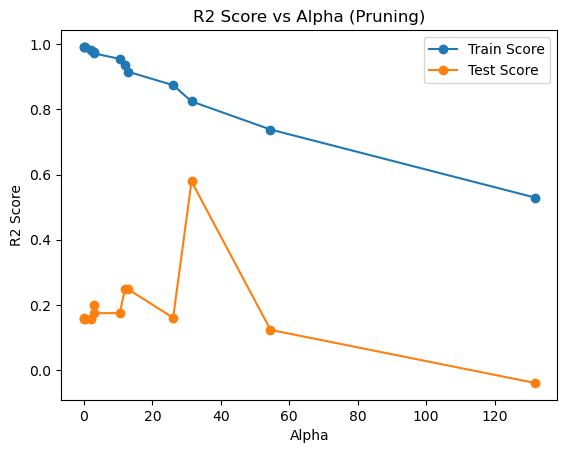

Best Alpha: 31.434074074074086
Train R2: 0.8244189709293963
Test R2: 0.5790341396891896


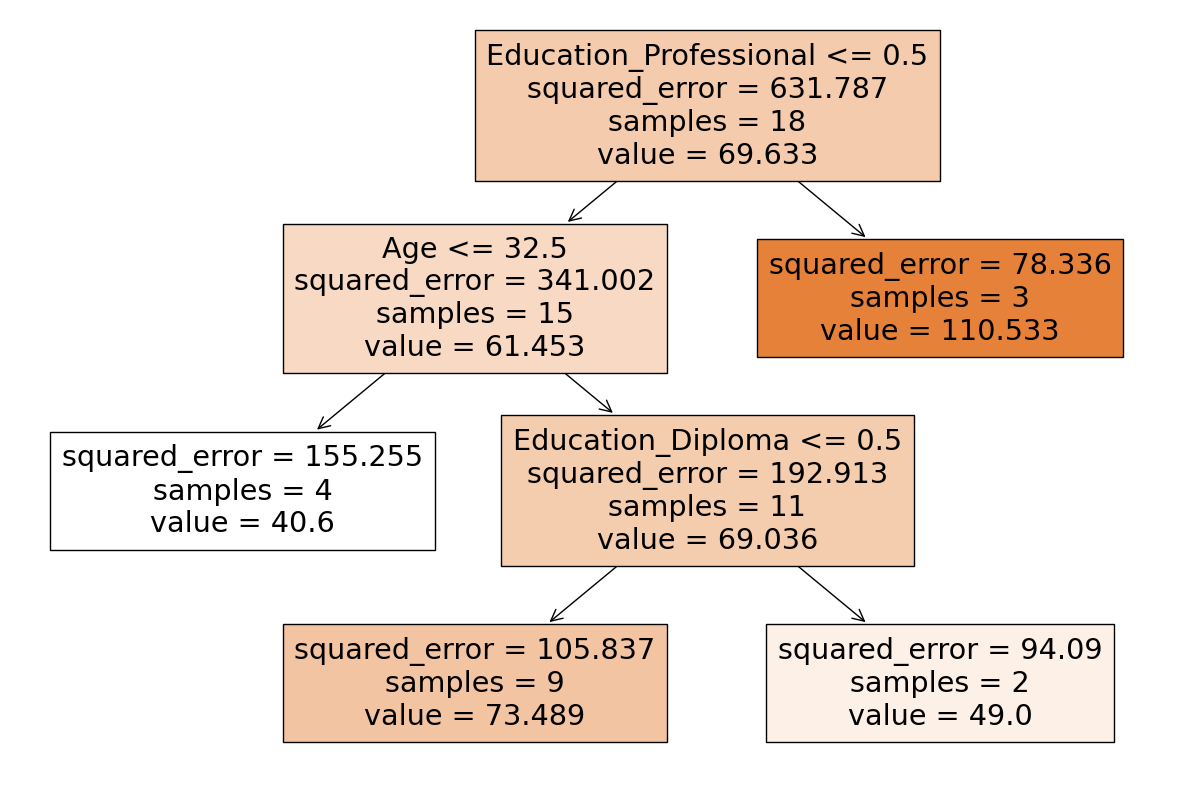

In [7]:
# Get pruning path
path = regressor.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Remove last alpha (over-pruned tree)
ccp_alphas = ccp_alphas[:-1]

train_scores = []
test_scores = []

# Train models for each alpha
for alpha in ccp_alphas:
    regressor_ = DecisionTreeRegressor(random_state=1234, ccp_alpha=alpha)
    model_ = regressor_.fit(X_train, y_train)

    train_scores.append(model_.score(X_train, y_train))
    test_scores.append(model_.score(X_test, y_test))

# Plot results
plt.plot(ccp_alphas, train_scores, marker="o", label="Train Score")
plt.plot(ccp_alphas, test_scores, marker="o", label="Test Score")

plt.xlabel("Alpha")
plt.ylabel("R2 Score")
plt.legend()
plt.title("R2 Score vs Alpha (Pruning)")
plt.show()


# Best alpha selection
best_alpha = ccp_alphas[test_scores.index(max(test_scores))]
print("Best Alpha:", best_alpha)

# Final pruned model
final_model = DecisionTreeRegressor(random_state=1234, ccp_alpha=best_alpha)
final_model.fit(X_train, y_train)

print("Train R2:", final_model.score(X_train, y_train))
print("Test R2:", final_model.score(X_test, y_test))


# Visualize pruned tree
plt.figure(figsize=(15, 10))
tree.plot_tree(final_model,
               feature_names=X_train.columns,
               filled=True)
plt.show()